In [9]:
import sqlite3
#python build-in database library,allows to create,connect to and query sqlite database,no pip install needed
import pandas as pd
#
import matplotlib.pyplot as plt
#used to create bar graphs,histograms..
import warnings
warnings.filterwarnings('ignore')


In [12]:
df=pd.read_csv('student_performance.csv')
print("No of Rows:",df.shape[0])
print("No of Columns:",df.shape[1])

No of Rows: 30
No of Columns: 13


In [13]:
#sqlite3.connect()-creates or opens a database file
#conn- connection object-our link to the database
#cursor- tool that executes that sql commands
#df.to_sql-writes the dataframes as a database tables

#STEP-1 Connect to a database file
conn=sqlite3.connect('college.db')
#STEP-2 Create a Cusor- SQL Execution tool
cursor=conn.cursor()
#STEP-3 Write the dataframe to a database table
df.to_sql(
    name='students',
    con=conn,
    index=False,    #index starts with 1
    if_exists='replace'
)
#STEP-4 Verify table was created or not
cursor.execute("SELECT COUNT(*) FROM students")

count=cursor.fetchone()[0]
#fetchone() retrives the first result row
#[0] gets the first value from that row

print(f"Database 'college.db' created successfully!")
print(f"Number of rows in the 'students' table: {count}")


Database 'college.db' created successfully!
Number of rows in the 'students' table: 30


In [7]:
cursor.execute("SELECT * from students")
result=cursor.fetchall()
print(result)
print("-"*1000)
cursor.execute("SELECT * from students")
result2=cursor.fetchone()
print(result2)

[(1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023), (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023), (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023), (1004, 'Sneha Reddy', 20, 'Female', 'Mechanical', 2, 70, 80, 75, 48, 95, 'Hyderabad', 2023), (1005, 'Arjun Nair', 19, 'Male', 'Computer Science', 2, 92, 88, 81, 95, 90, 'Kochi', 2023), (1006, 'Meera Joshi', 20, 'Female', 'Electronics', 2, 58, 66, 70, 52, 72, 'Pune', 2023), (1007, 'Kiran Kumar', 21, 'Male', 'Civil', 2, 73, 69, 65, 40, 85, 'Bangalore', 2023), (1008, 'Divya Singh', 19, 'Female', 'Computer Science', 2, 88, 91, 84, 93, 96, 'Lucknow', 2023), (1009, 'Rahul Mishra', 20, 'Male', 'Mechanical', 2, 62, 71, 58, 45, 68, 'Varanasi', 2023), (1010, 'Ananya Das', 19, 'Female', 'Computer Science', 2, 95, 89, 90, 97, 98, 'Kolkata', 2023), (1011, 'Vikram Iyer', 20, 'Male', 'Electronics', 2, 80, 75, 68, 72, 83, '

In [17]:
cursor.execute("PRAGMA table_info(students)")

columns_info = cursor.fetchall()

print("Table Structure of 'students':")
print(f"{'Column Name':<25}{'Data Types':<12}")
print("-" * 30)

for column in columns_info:
    print(f"{column[1]:<25}{column[2]:<12}")

Table Structure of 'students':
Column Name              Data Types  
------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


In [18]:
def run_query(sql,description=""):
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"{'-'*55}")
  result=pd.read_sql_query(sql,conn)
  return result

In [11]:
query1="""
select student_id,name,department,math_score,attendance_percentage
from students
limit 10
"""
result1=run_query(query1,"Query 1: First 10 Students(SELECT + LIMIT)")
print(result1)


Query 1: First 10 Students(SELECT + LIMIT)
-------------------------------------------------------
   student_id          name        department  math_score  \
0        1001  Aarav Sharma  Computer Science          85   
1        1002   Priya Patel  Computer Science          76   
2        1003   Rohit Verma       Electronics          65   
3        1004   Sneha Reddy        Mechanical          70   
4        1005    Arjun Nair  Computer Science          92   
5        1006   Meera Joshi       Electronics          58   
6        1007   Kiran Kumar             Civil          73   
7        1008   Divya Singh  Computer Science          88   
8        1009  Rahul Mishra        Mechanical          62   
9        1010    Ananya Das  Computer Science          95   

   attendance_percentage  
0                     92  
1                     87  
2                     78  
3                     95  
4                     90  
5                     72  
6                     85  
7           

In [12]:
query1 = """
SELECT student_id, name, department, math_score, attendance_percentage
FROM students
ORDER BY student_id DESC
LIMIT 5
"""

result1 = run_query(query1, "Query 1: Last 5 Students")

print(result1)


Query 1: Last 5 Students
-------------------------------------------------------
   student_id            name        department  math_score  \
0        1030  Akanksha Yadav  Computer Science          91   
1        1029      Nitin Jain        Mechanical          75   
2        1028   Sunita Pillai             Civil          60   
3        1027   Gaurav Shukla  Computer Science          84   
4        1026      Rekha Nair       Electronics          72   

   attendance_percentage  
0                     95  
1                     84  
2                     73  
3                     87  
4                     82  


In [13]:
query1 = """
SELECT student_id, name, science_score, math_score, english_score, programming_score
FROM students
WHERE student_id BETWEEN 1026 AND 1030
ORDER BY student_id ASC
"""
result1 = run_query(query1, "Query 1: Last 5 Students")

print(result1)


Query 1: Last 5 Students
-------------------------------------------------------
   student_id            name  science_score  math_score  english_score  \
0        1026      Rekha Nair             77          72             73   
1        1027   Gaurav Shukla             79          84             75   
2        1028   Sunita Pillai             65          60             68   
3        1029      Nitin Jain             76          75             70   
4        1030  Akanksha Yadav             93          91             87   

   programming_score  
0                 63  
1                 87  
2                 39  
3                 50  
4                 94  


In [14]:
query1 = """
SELECT  name, department, math_score
FROM students
ORDER BY math_score DESC
LIMIT 5
"""
result1 = run_query(query1, "Query 1: Last 5 Students")

print(result1)



Query 1: Last 5 Students
-------------------------------------------------------
             name        department  math_score
0      Ananya Das  Computer Science          95
1     Tanvi Mehta  Computer Science          93
2      Arjun Nair  Computer Science          92
3  Akanksha Yadav  Computer Science          91
4  Swati Kulkarni  Computer Science          90


In [15]:
query2 = """
SELECT  name, department,programming_score
FROM students
WHERE programming_score BETWEEN 50 AND 75
ORDER BY programming_score ASC
"""
result2 = run_query(query2, "Query 2: Programming score Between 50 and 75:")

print(result2)


Query 2: Programming score Between 50 and 75:
-------------------------------------------------------
            name   department  programming_score
0     Nitin Jain   Mechanical                 50
1  Kavya Nambiar   Mechanical                 51
2    Meera Joshi  Electronics                 52
3  Preeti Saxena   Mechanical                 53
4    Rohit Verma  Electronics                 55
5  Harish Pillai  Electronics                 58
6     Rekha Nair  Electronics                 63
7   Ritu Agarwal  Electronics                 69
8    Vikram Iyer  Electronics                 72


In [19]:
query3= """
SELECT name,math_score,science_score,programming_score,attendance_percentage
FROM students
WHERE department = 'Computer Science'
ORDER BY programming_score DESC
"""
result3=run_query(query3,"Query 3: Computer Science Students")
print(result3)


Query 3: Computer Science Students
-------------------------------------------------------
              name  math_score  science_score  programming_score  \
0       Ananya Das          95             89                 97   
1      Tanvi Mehta          93             90                 96   
2       Arjun Nair          92             88                 95   
3   Akanksha Yadav          91             93                 94   
4      Divya Singh          88             91                 93   
5   Swati Kulkarni          90             87                 92   
6     Aarav Sharma          85             78                 91   
7        Amit Bose          86             82                 89   
8       Suresh Rao          83             86                 88   
9    Gaurav Shukla          84             79                 87   
10    Nisha Kapoor          79             84                 83   
11     Priya Patel          76             82                 79   
12     Ajay Tiwari      

In [23]:
query3= """
SELECT name,programming_score
FROM students
WHERE department IN ('Computer Science','Electronic','Mechanical')
ORDER BY programming_score DESC
LIMIT 1
"""
result3=run_query(query3,"Query 3: Top Programming Score Student")
print(result3)


Query 3: Top Programming Score Student
-------------------------------------------------------
         name  programming_score
0  Ananya Das                 97


In [24]:
query4 = """
SELECT name,department,attendance_percentage
FROM students
WHERE attendance_percentage > 90
AND department != 'Civil'
ORDER BY attendance_percentage DESC
"""
result4 = run_query(query4, "Query 4: Students with Attendance Percentage > 90")

print(result4)


Query 4: Students with Attendance Percentage > 90
-------------------------------------------------------
             name        department  attendance_percentage
0      Ananya Das  Computer Science                     98
1     Tanvi Mehta  Computer Science                     97
2     Divya Singh  Computer Science                     96
3     Sneha Reddy        Mechanical                     95
4  Akanksha Yadav  Computer Science                     95
5  Swati Kulkarni  Computer Science                     94
6    Ritu Agarwal       Electronics                     93
7    Aarav Sharma  Computer Science                     92
8   Kavya Nambiar        Mechanical                     91
9       Amit Bose  Computer Science                     91


In [25]:
query5 = """
SELECT name,department,attendance_percentage
FROM students
WHERE attendance_percentage != 90
ORDER BY attendance_percentage DESC
"""
result5 = run_query(query5, "Query 4: Students with Attendance Percentage > 90")

print(result5)


Query 4: Students with Attendance Percentage > 90
-------------------------------------------------------
              name        department  attendance_percentage
0     Nisha Kapoor  Computer Science                     89
1       Suresh Rao  Computer Science                     88
2      Priya Patel  Computer Science                     87
3    Gaurav Shukla  Computer Science                     87
4    Preeti Saxena        Mechanical                     86
5       Nitin Jain        Mechanical                     84
6      Vikram Iyer       Electronics                     83
7       Rekha Nair       Electronics                     82
8      Rohit Verma       Electronics                     78
9   Deepak Chauhan        Mechanical                     77
10     Ajay Tiwari  Computer Science                     75
11   Harish Pillai       Electronics                     74
12     Meera Joshi       Electronics                     72
13    Rahul Mishra        Mechanical                 

In [14]:
import pandas as pd
dept_data={
    'dept_code':['CS','EC','ME','CE'],
    'dept_name':['Computer Science','Electronics','Mechanical','Civil'],
    'Hod_name':['Dr. A','Dr. B','Dr. C','Dr. D'],
    'established':[1985,1988,1972,1965],
    'intake':[60,60,60,60]
}
dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("created 'department table")
print(dept_df.to_string(index=False))
dept_map={
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE'
}

created 'department table
dept_code        dept_name Hod_name  established  intake
       CS Computer Science    Dr. A         1985      60
       EC      Electronics    Dr. B         1988      60
       ME       Mechanical    Dr. C         1972      60
       CE            Civil    Dr. D         1965      60


In [7]:
query_join="""
SELECT
s.name,s.math_Score,
d.hod_name,
d.established
FROM students AS s
INNER JOIN departments AS s
 ON s.dept_code=d.dept_code
 ORDER BY s.math_score DESC
 LIMIT 8
"""

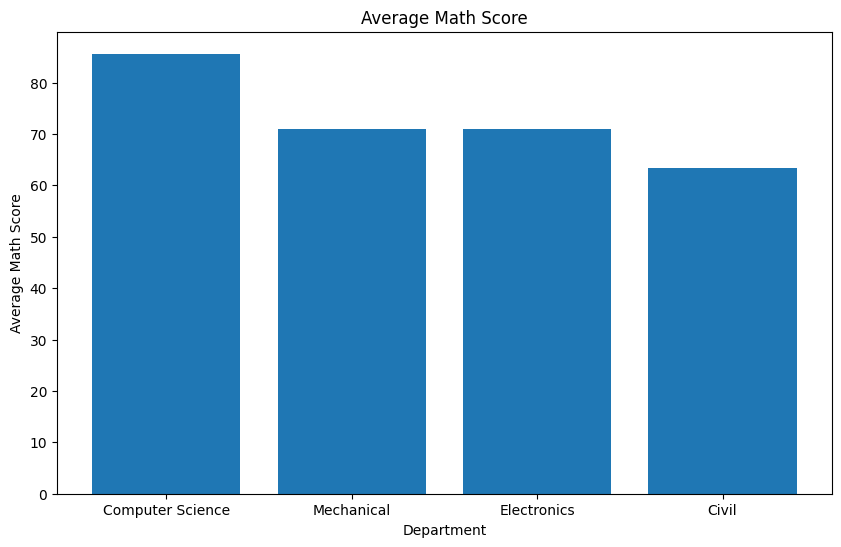

In [15]:
chart1_sql = """
SELECT department,
ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
chart1_data = pd.read_sql_query(chart1_sql, conn)
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(
    chart1_data['department'],
    chart1_data['avg_math']
)

ax.set_title("Average Math Score")
ax.set_xlabel("Department")
ax.set_ylabel("Average Math Score")

plt.show()

In [19]:
query_join = """
SELECT
s.name,
s.math_score,
d.hod_name,
d.established
FROM students AS s
INNER JOIN departments AS d
ON s.department = d.dept_name
ORDER BY s.math_score DESC
LIMIT 8
"""

result = run_query(query_join, "Top 8 Students with Department Details")

print(result)


Top 8 Students with Department Details
-------------------------------------------------------
             name  math_score Hod_name  established
0      Ananya Das          95    Dr. A         1985
1     Tanvi Mehta          93    Dr. A         1985
2      Arjun Nair          92    Dr. A         1985
3  Akanksha Yadav          91    Dr. A         1985
4  Swati Kulkarni          90    Dr. A         1985
5     Divya Singh          88    Dr. A         1985
6    Ritu Agarwal          87    Dr. B         1988
7       Amit Bose          86    Dr. A         1985


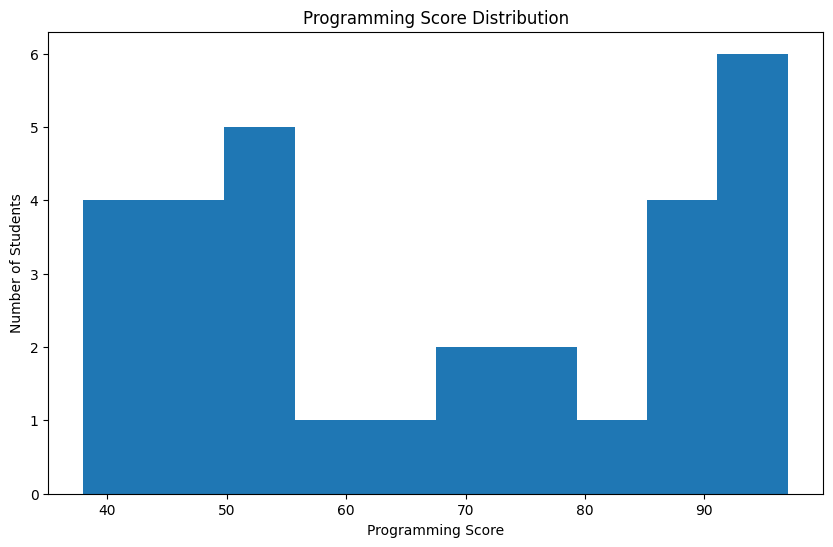

In [20]:
chart1_sql = """
SELECT programming_score
FROM students
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10,6))

ax.hist(
    chart1_data['programming_score'],
    bins=10
)

ax.set_title("Programming Score Distribution")
ax.set_xlabel("Programming Score")
ax.set_ylabel("Number of Students")

plt.show()

Day - 2 - Mini Project

SQLQUERY
# Panel 1 data: avg math by department
# Panel 2 data: student count by department
# Panel 3 data: top 8 students by total score
# Panel 4 data: gender-wise average attendance


Matplotlib
# ── Panel 1 (top-left): Avg Math by Department - BAR Chart ──
# ── Panel 2 (top-right): Student Count Pie Chart
# ── Panel 3 (bottom-left): Top 8 Students Horizontal Bar ──
# ── Panel 4 (bottom-right): Gender Avg Attendance Bar ──

Practice Questions
Question 1: Write a SQL query to find the average programming score for female students only.

Question 2: What is the difference between WHERE and HAVING? Write one example of each using the students table.

Question 3: Write a SQL query to find all departments where the average attendance is above 85%.

Question 4: What does pd.read_sql_query() return? What two arguments does it require?

Question 5: Modify Chart 1 (bar chart) to show average PROGRAMMING scores instead of math scores.

In [21]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [22]:
panel1_sql = """
SELECT department,
ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

panel1_data = pd.read_sql_query(panel1_sql, conn)

print(panel1_data)

         department  avg_math
0  Computer Science     85.62
1        Mechanical     71.00
2       Electronics     71.00
3             Civil     63.40


In [23]:
panel2_sql = """
SELECT department,
COUNT(*) AS student_count
FROM students
GROUP BY department
"""

panel2_data = pd.read_sql_query(panel2_sql, conn)

print(panel2_data)

         department  student_count
0             Civil              5
1  Computer Science             13
2       Electronics              6
3        Mechanical              6


In [33]:
panel3_sql = """
SELECT name,
(math_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

panel3_data = pd.read_sql_query(panel3_sql, conn)

print(panel3_data)

             name  total_score
0      Ananya Das          192
1     Tanvi Mehta          189
2      Arjun Nair          187
3  Akanksha Yadav          185
4  Swati Kulkarni          182
5     Divya Singh          181
6    Aarav Sharma          176
7       Amit Bose          175


In [25]:
panel4_sql = """
SELECT gender,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY gender
"""

panel4_data = pd.read_sql_query(panel4_sql, conn)

print(panel4_data)

   gender  avg_attendance
0  Female           88.53
1    Male           80.47


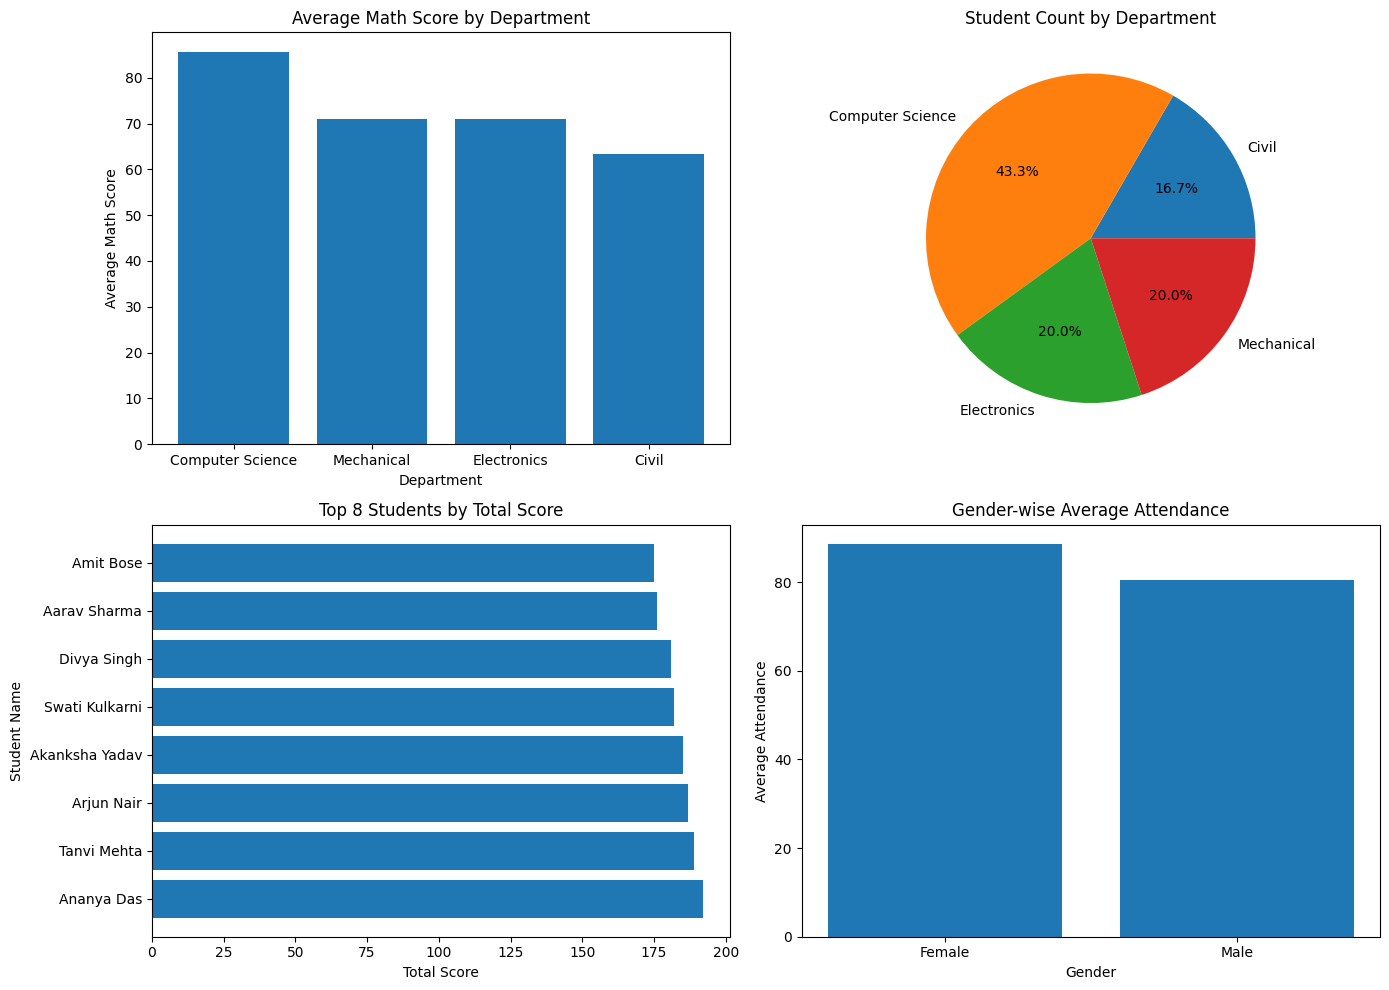

In [34]:
fig, axs = plt.subplots(2, 2, figsize=(14,10))

# Panel 1
axs[0,0].bar(
    panel1_data['department'],
    panel1_data['avg_math']
)

axs[0,0].set_title("Average Math Score by Department")
axs[0,0].set_xlabel("Department")
axs[0,0].set_ylabel("Average Math Score")


# Panel 2
axs[0,1].pie(
    panel2_data['student_count'],
    labels=panel2_data['department'],
    autopct='%1.1f%%'
)

axs[0,1].set_title("Student Count by Department")


# Panel 3
axs[1,0].barh(
    panel3_data['name'],
    panel3_data['total_score']
)

axs[1,0].set_title("Top 8 Students by Total Score")
axs[1,0].set_xlabel("Total Score")
axs[1,0].set_ylabel("Student Name")

# Panel 4
axs[1,1].bar(
    panel4_data['gender'],
    panel4_data['avg_attendance']
)

axs[1,1].set_title("Gender-wise Average Attendance")
axs[1,1].set_xlabel("Gender")
axs[1,1].set_ylabel("Average Attendance")


plt.tight_layout()
plt.show()

In [27]:
q1 = """
SELECT ROUND(AVG(programming_score),2) AS avg_programming
FROM students
WHERE gender = 'Female'
"""

q1_result = pd.read_sql_query(q1, conn)

print(q1_result)

   avg_programming
0             70.2


In [28]:
where_query = """
SELECT *
FROM students
WHERE attendance_percentage > 85
"""

where_result = pd.read_sql_query(where_query, conn)

print(where_result.head())

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1004   Sneha Reddy   20  Female        Mechanical         2   
3        1005    Arjun Nair   19    Male  Computer Science         2   
4        1008   Divya Singh   19  Female  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          70             80             75                 48   
3          92             88             81                 95   
4          88             91             84                 93   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2       

In [35]:
having_query = """
SELECT department,
AVG(math_score + programming_score) AS avg_total
FROM students
GROUP BY department
HAVING AVG(math_score + programming_score) > 150
"""

having_result = pd.read_sql_query(having_query, conn)

print(having_result)

         department   avg_total
0  Computer Science  174.846154


In [30]:
q3 = """
SELECT department,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85
"""

q3_result = pd.read_sql_query(q3, conn)

print(q3_result)

         department  avg_attendance
0  Computer Science           90.69


In [31]:
print("""
pd.read_sql_query() returns a pandas DataFrame.

Required arguments:
1. SQL query
2. Database connection object
""")


pd.read_sql_query() returns a pandas DataFrame.

Required arguments:
1. SQL query
2. Database connection object



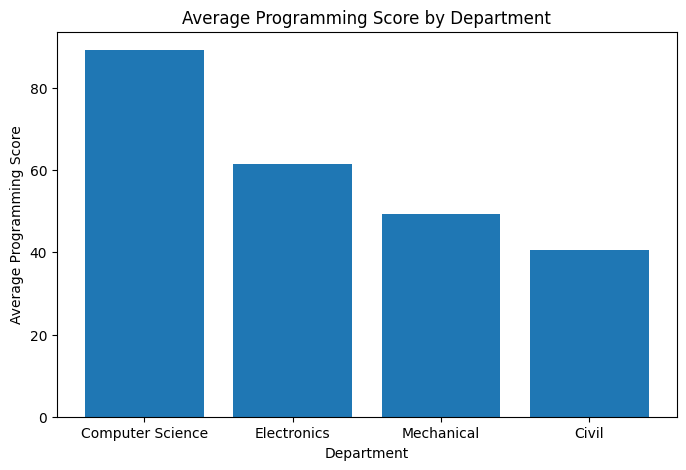

In [32]:
q5_sql = """
SELECT department,
ROUND(AVG(programming_score),2) AS avg_programming
FROM students
GROUP BY department
ORDER BY avg_programming DESC
"""

q5_data = pd.read_sql_query(q5_sql, conn)

plt.figure(figsize=(8,5))

plt.bar(
    q5_data['department'],
    q5_data['avg_programming']
)

plt.title("Average Programming Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Programming Score")

plt.show()